In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [22]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

portfolio = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

In [23]:
print(nav.columns.tolist())

print(transactions.columns.tolist())

print(performance.columns.tolist())

print(portfolio.columns.tolist())

['amfi_code', 'date', 'nav']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [24]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [25]:
risk_metrics = []

for fund in nav['amfi_code'].unique():

    returns = nav.loc[
        nav['amfi_code'] == fund,
        'daily_return'
    ].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[
        returns <= var95
    ].mean()

    risk_metrics.append([
        fund,
        var95,
        cvar95
    ])

var_cvar_report = pd.DataFrame(
    risk_metrics,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [26]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [27]:
top5 = (
    performance
    .sort_values(
        'aum_crore',
        ascending=False
    )
    .head(5)
)['amfi_code']

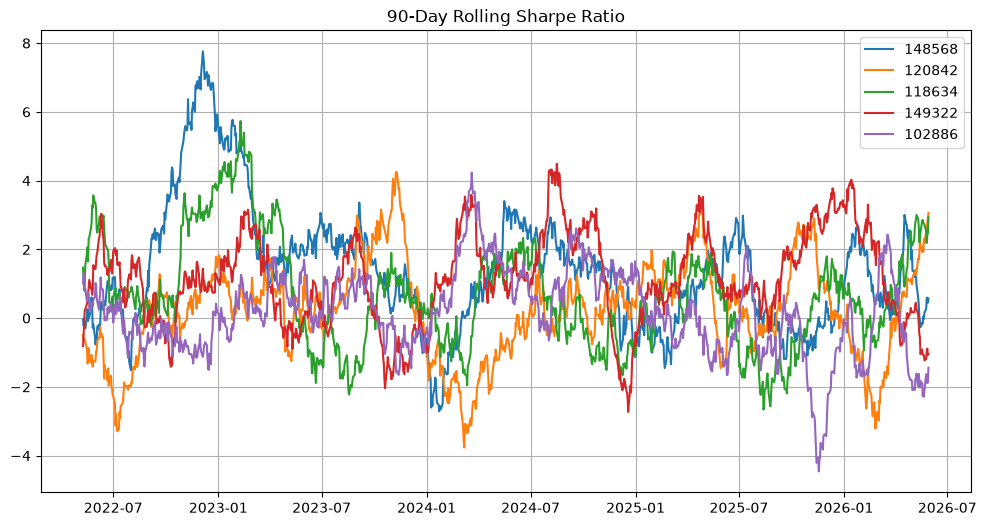

In [28]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches='tight'
)

plt.show()

In [29]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [30]:
cohort = (
    transactions.groupby('investor_id')
    ['transaction_date']
    .min()
    .dt.year
    .reset_index()
)

cohort.columns = [
    'investor_id',
    'cohort_year'
]

In [31]:
transactions = transactions.merge(
    cohort,
    on='investor_id'
)

In [32]:
cohort_summary = (
    transactions.groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum')
    )
)

cohort_summary

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [33]:
top_fund = (
    transactions.groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund.sort_values(
        ['cohort_year','count'],
        ascending=False
    )
    .drop_duplicates('cohort_year')
)

top_fund.head()

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


In [34]:
sip = transactions[
    transactions['transaction_type']
    .str.upper()
    == 'SIP'
].copy()

In [35]:
sip_count = (
    sip.groupby('investor_id')
    .size()
)

In [36]:
eligible = sip_count[
    sip_count >= 6
].index

In [37]:
sip = sip[
    sip['investor_id']
    .isin(eligible)
]

In [38]:
results = []

for investor in sip['investor_id'].unique():

    temp = sip[
        sip['investor_id']==investor
    ].sort_values('transaction_date')

    avg_gap = (
        temp['transaction_date']
        .diff()
        .dt.days
        .mean()
    )

    status = (
        "At Risk"
        if avg_gap > 35
        else "Healthy"
    )

    results.append([
        investor,
        avg_gap,
        status
    ])

sip_continuity = pd.DataFrame(
    results,
    columns=[
        'investor_id',
        'avg_gap_days',
        'status'
    ]
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV003054,78.666667,At Risk
1,INV001497,63.000000,At Risk
2,INV000786,64.125000,At Risk
3,INV003670,70.857143,At Risk
4,INV001023,72.428571,At Risk


In [39]:
# HHI Calculation

portfolio['weight_sq'] = (
    portfolio['weight_pct'] / 100
) ** 2

hhi = (
    portfolio.groupby('amfi_code')['weight_sq']
    .sum()
    .reset_index()
)

hhi.columns = ['amfi_code', 'HHI']

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [40]:
hhi['concentration'] = np.where(
    hhi['HHI'] > 0.25,
    'Highly Concentrated',
    np.where(
        hhi['HHI'] > 0.15,
        'Moderately Concentrated',
        'Diversified'
    )
)

hhi.sort_values('HHI', ascending=False).head(10)

,amfi_code,HHI,concentration
11,119092,0.206448,Moderately Concentrated
3,101207,0.200700,Moderately Concentrated
18,119599,0.174751,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated
7,118632,0.168298,Moderately Concentrated
29,148568,0.167930,Moderately Concentrated
21,120505,0.157570,Moderately Concentrated
22,120506,0.153794,Moderately Concentrated
27,125498,0.152414,Moderately Concentrated
23,120841,0.149680,Diversified


In [41]:
import os

print("VaR Report:", os.path.exists("../reports/var_cvar_report.csv"))
print("Rolling Sharpe Chart:", os.path.exists("../reports/rolling_sharpe_chart.png"))

VaR Report: True
Rolling Sharpe Chart: True


In [42]:
var_cvar_report.sort_values("VaR_95").head(1)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384


In [43]:
var_cvar_report.sort_values("CVaR_95").head(1)

,amfi_code,VaR_95,CVaR_95
4,101207,-0.026021,-0.032459


In [44]:
cohort_summary.sort_values(
    "total_invested",
    ascending=False
).head(1)

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187


In [45]:
sip_continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [46]:
total = len(sip_continuity)

healthy = (
    (sip_continuity["status"] == "Healthy")
    .sum()
)

healthy_pct = healthy / total * 100

print(round(healthy_pct,2))

2.2


In [47]:
hhi.sort_values(
    "HHI",
    ascending=False
).head(1)

,amfi_code,HHI,concentration
11,119092,0.206448,Moderately Concentrated



# Advanced Insights

### 1. Downside Risk Analysis
Fund 119599 has the highest 95% VaR of -0.026859, indicating the largest potential daily downside risk among all schemes.

### 2. Tail Risk Analysis
Fund 101207 recorded the lowest CVaR of -0.032459, suggesting the highest expected loss during extreme market downturns.

### 3. Investor Cohort Behaviour
The 2024 investor cohort contributed the highest total investment of ₹3,491,125,187, making it the most valuable investor segment.

### 4. SIP Continuity Analysis
Out of 1,362 eligible SIP investors, only 30 maintained healthy contribution patterns while 1,332 were classified as at-risk. Approximately 97.8% of investors showed SIP discontinuity risk.

### 5. Portfolio Concentration Analysis
Fund 119092 has the highest HHI score of 0.206448, indicating a moderately concentrated portfolio with greater sector exposure than its peers.